## Modelo S com Optuna
Optuna é uma ferramenta para a otimização de hiperparâmetros. A otimização de hiperparâmetros é um passo crucial para melhorar o desempenho de modelos, pois os hiperparâmetros controlam a forma como o modelo é treinado e avaliado.

In [ ]:
# imports
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
import optuna
import tensorflow as tf
from keras import layers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [2]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [3]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.2),
])

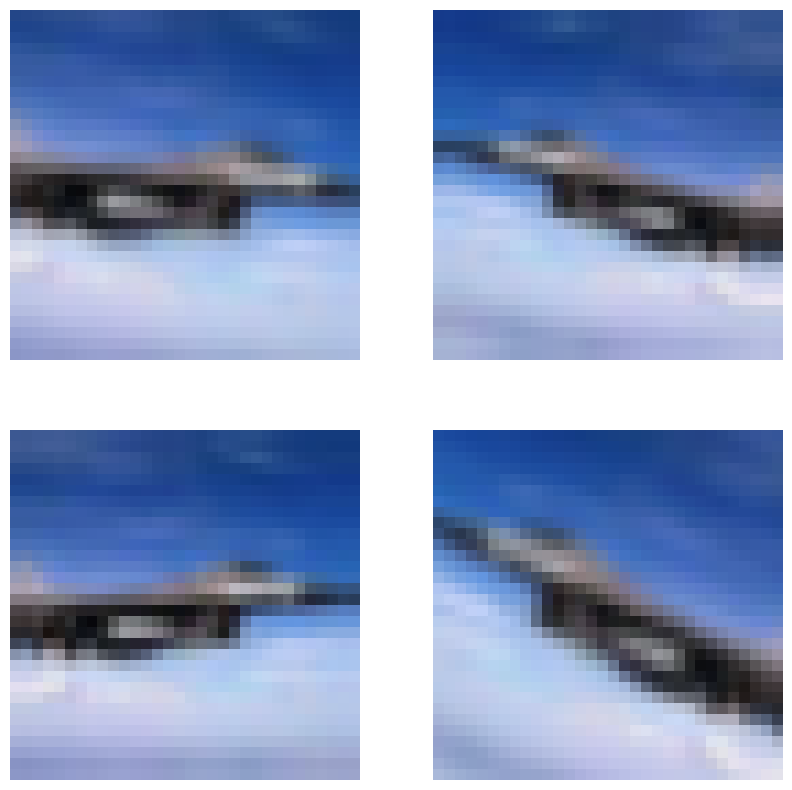

In [4]:
# apresentar 4 primeiras imagens da primeira batch
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(4):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

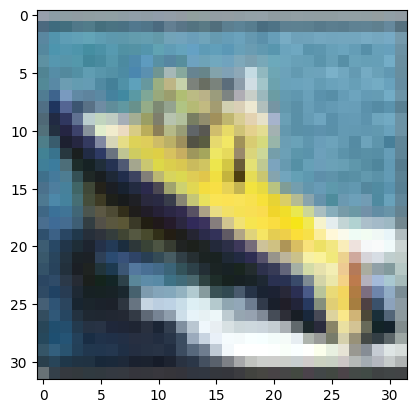

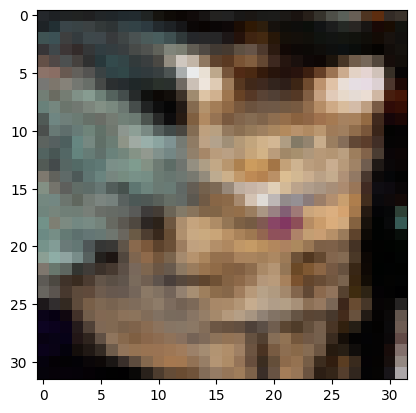

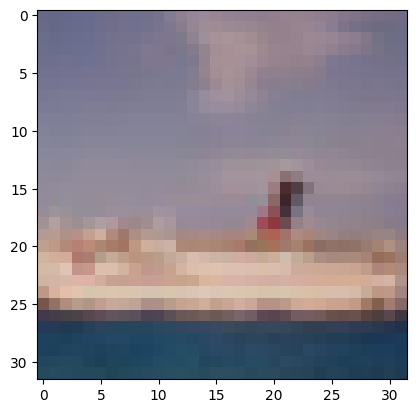

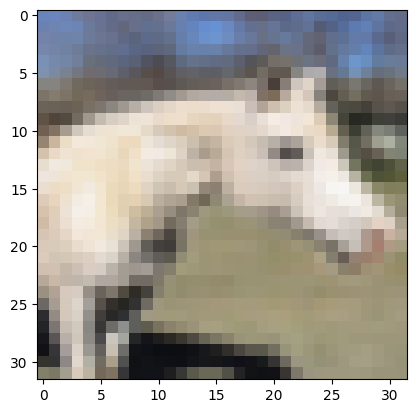

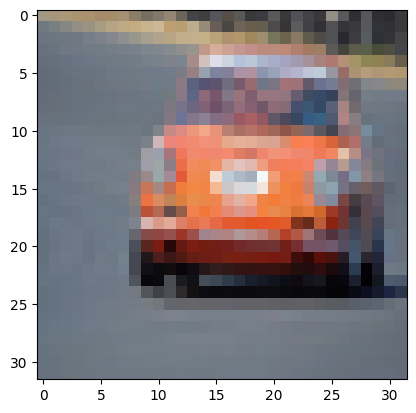

In [5]:
for data_batch, _ in train_dataset.take(1):
  for i in range(5):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

Grande parte do código em baixo coincide com o do modelo_s.ipynb. O funcionamento do Optuna é simples: é definido um espaço de busca para os hiperparâmetros e o Optuna encontra a melhor combinação de hiperparâmetros dentro desse espaço.
Por exemplo em l2_regularizer, é inserido o espaço de busca, neste caso entre 1e-4 e 1e-2 e o Optuna procurará o valor (dentro desse intervalo) que resultará na melhor accuracy.

In [6]:

model_filename = 'model_s.keras'

# using optuna to optimize hyperparameters
def objective(trial):
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    l2_regularizer = trial.suggest_float('l2_regularizer', 1e-4, 1e-2)
    dropout1 = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2 = trial.suggest_float('dropout2', 0.0, 0.5)
    dropout3 = trial.suggest_float('dropout3', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2)

    x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Dropout(dropout1)(x)

    x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)

    x = layers.Dropout(dropout2)(x)
    x = layers.Dense(100, activation="relu")(x)
    x = layers.Dropout(dropout3)(x)
    x = layers.Dense(25, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning_rate), metrics=['acc'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # para salvar o melhor modelo
    checkpoint_callback = ModelCheckpoint(
        model_filename,
        monitor='val_acc', 
        save_best_only=True,
        mode='max',
        save_weights_only=False
    )

    # Training the model
    history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])

    val_loss, val_accuracy = model.evaluate(validation_dataset, verbose=0)
    
    return val_accuracy

In [7]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, timeout=10000)

study.best_params

[I 2024-06-21 22:17:03,983] A new study created in memory with name: no-name-bb00e32d-88e4-42ad-b1a2-de3aef0581f7


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - acc: 0.1398 - loss: 4.7737 - val_acc: 0.2029 - val_loss: 2.2224
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - acc: 0.2230 - loss: 2.0903 - val_acc: 0.2555 - val_loss: 1.9485
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - acc: 0.2511 - loss: 2.0310 - val_acc: 0.2607 - val_loss: 1.9508
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2428 - loss: 2.0234 - val_acc: 0.2666 - val_loss: 1.9351
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.2479 - loss: 2.0088 - val_acc: 0.2540 - val_loss: 1.9444
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.2410 - loss: 2.0136 - val_acc: 0.2634 - val_loss: 1.9601
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.2431 - loss: 2.0187 - val_acc: 0.2647 - val_loss: 1.9321
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2427 - loss: 2.0154 - val_acc: 0.2290 - val_loss: 2.0831
Epoch 9/100
1250

[I 2024-06-21 22:29:13,688] Trial 0 finished with value: 0.28519999980926514 and parameters: {'l2_regularizer': 0.006751290160212115, 'dropout1': 0.41771977863731236, 'dropout2': 0.33762585975271103, 'dropout3': 0.24046992052065758, 'learning_rate': 0.004800806963785829}. Best is trial 0 with value: 0.28519999980926514.


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - acc: 0.1545 - loss: 4.0829 - val_acc: 0.2079 - val_loss: 2.3191
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2647 - loss: 2.0002 - val_acc: 0.2888 - val_loss: 1.9448
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2846 - loss: 1.9673 - val_acc: 0.2644 - val_loss: 1.9707
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2921 - loss: 1.9567 - val_acc: 0.3309 - val_loss: 1.8522
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.2967 - loss: 1.9432 - val_acc: 0.2304 - val_loss: 2.1890
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - acc: 0.2967 - loss: 1.9412 - val_acc: 0.1817 - val_loss: 2.2014
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.3016 - loss: 1.9315 - val_acc: 0.3344 - val_loss: 1.8064
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - acc: 0.3058 - loss: 1.9207 - val_acc: 0.3263 - val_loss: 1.8341
Epoch 9/100
1250

[I 2024-06-21 22:40:03,994] Trial 1 finished with value: 0.3467000126838684 and parameters: {'l2_regularizer': 0.009580699489574273, 'dropout1': 0.3742180202674905, 'dropout2': 0.07919998682477447, 'dropout3': 0.4312662369782229, 'learning_rate': 0.003420403226617607}. Best is trial 1 with value: 0.3467000126838684.


...

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - acc: 0.1316 - loss: 4.2045 - val_acc: 0.3046 - val_loss: 1.9912
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.2935 - loss: 1.9931 - val_acc: 0.4256 - val_loss: 1.6407
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.4053 - loss: 1.7075 - val_acc: 0.5273 - val_loss: 1.4396
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - acc: 0.4813 - loss: 1.5413 - val_acc: 0.5422 - val_loss: 1.3875
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.5199 - loss: 1.4411 - val_acc: 0.5942 - val_loss: 1.2534
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.5531 - loss: 1.3705 - val_acc: 0.5897 - val_loss: 1.2891
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - acc: 0.5826 - loss: 1.3052 - val_acc: 0.6228 - val_loss: 1.1727
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - acc: 0.5927 - loss: 1.2758 - val_acc: 0.6415 - val_loss: 1.1341
Epoch 9/100
1250

[I 2024-06-22 00:57:51,306] Trial 10 finished with value: 0.7490000128746033 and parameters: {'l2_regularizer': 0.005246618528743138, 'dropout1': 0.18420281590629337, 'dropout2': 0.48425336353132775, 'dropout3': 0.27434656101359467, 'learning_rate': 0.00024294247337593947}. Best is trial 10 with value: 0.7490000128746033.


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 32s 25ms/step - acc: 0.1210 - loss: 3.7320 - val_acc: 0.2716 - val_loss: 1.9561
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - acc: 0.2880 - loss: 1.9416 - val_acc: 0.4349 - val_loss: 1.6073
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.4032 - loss: 1.6637 - val_acc: 0.4868 - val_loss: 1.4858
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.4753 - loss: 1.5092 - val_acc: 0.5517 - val_loss: 1.3332
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.5182 - loss: 1.4303 - val_acc: 0.5800 - val_loss: 1.2836
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - acc: 0.5438 - loss: 1.3706 - val_acc: 0.6031 - val_loss: 1.1891
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - acc: 0.5655 - loss: 1.3179 - val_acc: 0.6025 - val_loss: 1.1848
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - acc: 0.5823 - loss: 1.2796 - val_acc: 0.6239 - val_loss: 1.1735
Epoch 9/100
1250

[I 2024-06-22 01:21:17,524] Trial 11 finished with value: 0.7110000252723694 and parameters: {'l2_regularizer': 0.005148599099262786, 'dropout1': 0.18480949270583408, 'dropout2': 0.49495897926565025, 'dropout3': 0.28201387748152695, 'learning_rate': 0.00033811631277154777}. Best is trial 10 with value: 0.7490000128746033.


{'l2_regularizer': 0.005246618528743138,
 'dropout1': 0.18420281590629337,
 'dropout2': 0.48425336353132775,
 'dropout3': 0.27434656101359467,
 'learning_rate': 0.00024294247337593947}

Em cima aparecem aqueles que o Optuna considera serem os melhores parâmetros (obtidos no penultimo trial) para o modelo que, embora ligeiramente diferentes dos definidos no modelo_s.ipynb, resultam numa accuracy de validação bastante semelhante.
Conseguimos perceber pelos valores das accuracies de validação que o Optuna encontrou uma combinação de hiperparâmetros que resultou numa accuracy de validação bastante boa e em que não ocorre overfitting. 
Na transição de certos trials dá-se uma grande descida na accuracy que não seria de esperar. Uma das razões para tal acontecer pode ser o facto de que o Optuna, ao tentar encontrar melhores hiperparâmetros, por vezes altera valores bastante sensíveis que podem resultar em grandes descidas na accuracy. No entanto, apenas será salvo o modelo com os melhores parâmetros, logo esses serão descartados.

Exemplo de uma imagem corretamente classificada:

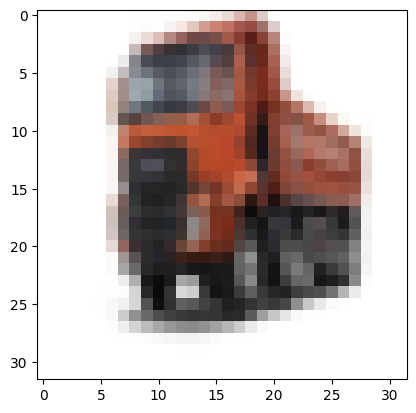

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Model predicts:  truck
Result:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
from keras.preprocessing import image
import numpy as np

img = tf.keras.preprocessing.image.load_img('truck.jpg', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())

**Nota**: devido à maneira como foi implementado, não conseguimos apresentar gráficos de evolução das accuracies.